# KarawangPadiGuard - EDA Dataset Sendiri + Kaggle Image Dataset

Notebook ini berisi EDA untuk proyek KarawangPadiGuard dengan aturan data berikut:

1. **Cuaca, satelit, dan produksi padi wajib berasal dari dataset yang kamu upload sendiri** ke Google Colab atau Google Drive.
2. **Tidak ada generator dataset sintetis** untuk cuaca, satelit, atau produksi padi.
3. **Dataset gambar penyakit padi tetap memakai Kaggle** melalui `kagglehub`, karena ukuran dataset gambar besar dan lebih efisien diakses langsung dari Kaggle.
4. Notebook tidak melakukan pencarian rekursif ke seluruh Google Drive agar tidak lambat.

Struktur folder yang disarankan di Google Drive:

```text
MyDrive/
└── Datathon/
    └── KarawangPadiGuard/
        └── data/
            ├── preprocess/
            │   ├── weather_scraped.csv
            │   ├── sentinel2_indices.csv
            │   └── dataset_produksi_padi_karawang_cleaned.csv
            ├── processed/
            └── raw/
```

Jika nama file berbeda, ubah daftar path pada cell **Konfigurasi Dataset Tabular**.

## 1. Setup Environment & Install Dependencies

In [ ]:
# 1. Setup Environment & Install Dependencies
import os
import sys
import subprocess
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

PLATFORM = None
try:
    import google.colab  # type: ignore
    PLATFORM = 'colab'
    print("Running on Google Colab")
except Exception:
    if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
        PLATFORM = 'kaggle'
        print("Running on Kaggle")
    else:
        PLATFORM = 'local'
        print("Running on Local Environment")


def install_if_missing(import_name, package_name=None):
    package_name = package_name or import_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

for import_name, package_name in [
    ('PIL', 'Pillow'),
    ('cv2', 'opencv-python-headless'),
    ('seaborn', 'seaborn'),
    ('sklearn', 'scikit-learn'),
    ('kagglehub', 'kagglehub'),
]:
    install_if_missing(import_name, package_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("\nLibraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

Running on Google Colab

Libraries imported successfully!
Analysis Date: 2026-05-28


## 2. GPU Check

In [ ]:
# 2. GPU Check
import torch
print("\n" + "="*60)
print("GPU INFORMATION")
print("="*60)

if torch.cuda.is_available():
    print(f"\n GPU is AVAILABLE!")
    print(f" GPU Count: {torch.cuda.device_count()}")
    print(f" GPU Name: {torch.cuda.get_device_name(0)}")
    print(f" CUDA Version: {torch.version.cuda}")
    print(f" Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("\n GPU is NOT available. Using CPU.")
    print(" For faster training, enable GPU in:")
    print(" Colab: Runtime > Change runtime type > T4 GPU")
    print(" Kaggle: Settings > Accelerator > GPU T4/P100")
print("\n" + "="*60)


GPU INFORMATION

 GPU is NOT available. Using CPU.
 For faster training, enable GPU in:
 Colab: Runtime > Change runtime type > T4 GPU
 Kaggle: Settings > Accelerator > GPU T4/P100



## 3. Load Dataset Gambar dari Kaggle

In [ ]:
# 3. Load Dataset Gambar dari Kaggle
# Dataset gambar penyakit padi memang dipertahankan dari Kaggle.
import kagglehub

path = kagglehub.dataset_download("anshulm257/rice-disease-dataset")

from pathlib import Path
import shutil
import zipfile

IMAGE_DATASET_PATH = None

print("Loading Rice Disease Dataset from Kaggle...\n")
print("Rice Disease Dataset (Images):")
print("-" * 50)

kaggle_dataset_path = Path(path)
preferred_image_path = kaggle_dataset_path / "Rice_Leaf_AUG"

if preferred_image_path.exists():
    IMAGE_DATASET_PATH = preferred_image_path
    print(f"Using folder: {IMAGE_DATASET_PATH}")
elif kaggle_dataset_path.exists():
    IMAGE_DATASET_PATH = kaggle_dataset_path
    print(f"Subfolder Rice_Leaf_AUG tidak ditemukan, menggunakan root: {IMAGE_DATASET_PATH}")
else:
    raise FileNotFoundError(f"Dataset Kaggle tidak ditemukan di path: {kaggle_dataset_path}")

if IMAGE_DATASET_PATH.exists():
    print(f"\nImage dataset confirmed: {IMAGE_DATASET_PATH}")
    print("Contents:")
    for item in sorted(IMAGE_DATASET_PATH.iterdir())[:10]:
        if item.is_dir():
            count = len(list(item.glob('*.jpg')) + list(item.glob('*.jpeg')) + list(item.glob('*.png')))
            print(f"- {item.name}/ ({count} images)")
        else:
            print(f"- {item.name}")

print("\n" + "="*50)
print("Image dataset loading complete!")
print("="*50)

Using Colab cache for faster access to the 'rice-disease-dataset' dataset.
Loading Rice Disease Dataset from Kaggle...

Rice Disease Dataset (Images):
--------------------------------------------------
Using folder: /kaggle/input/rice-disease-dataset/Rice_Leaf_AUG

Image dataset confirmed: /kaggle/input/rice-disease-dataset/Rice_Leaf_AUG
Contents:
- Bacterial Leaf Blight/ (636 images)
- Brown Spot/ (646 images)
- Healthy Rice Leaf/ (653 images)
- Leaf Blast/ (634 images)
- Leaf scald/ (628 images)
- Sheath Blight/ (632 images)

Image dataset loading complete!


In [ ]:
# 4. Konfigurasi Area Studi & Definisi Kelas
# Koordinat Karawang
KARAWANG_COORDS = {
    'name': 'Kabupaten Karawang',
    'center_lat': -6.3167,
    'center_lon': 107.2867,
    'bounds': {'min_lat': -6.5, 'max_lat': -6.1, 'min_lon': 107.2, 'max_lon': 107.7},
    'area_hectares': 70000,
    'rice_farmers': 50000
}

# Kecamatan di Karawang
KECAMATAN = [
    'Telukjambe', 'Klari', 'Cikampek', 'Pedes', 'Kotabaru',
    'Tempuran', 'Jatisari', 'Cilebar', 'Rawamerta', 'Tirtajaya',
    'Karawang Barat', 'Karawang Timur', 'Telukjambe Timur',
    'Cilamaya Kulon', 'Cilamaya Wetan', 'Pakisjaya', 'Batujaya',
    'Kutawaluya', 'Rengasdengklok', 'Jayakerta', 'Majalaya'
]

# Definisi 6 kelas penyakit padi
CLASSES = {
    'Bacterial Leaf Blight': {
        'nama_indonesia': 'Hawar Daun Bakteri',
        'pathogen': 'Xanthomonas oryzae pv. oryzae',
        'gejala': 'Daun mengering mulai dari ujung berwarna keabu-abuan',
        'yield_loss': '30-50%',
        'expected_count': 636,
        'optimal_temp': '25-30°C',
        'optimal_humidity': '>85%'
    },
    'Brown Spot': {
        'nama_indonesia': 'Bercak Coklat',
        'pathogen': 'Cochliobolus miyabeanus',
        'gejala': 'Bercak berbentuk oval berwarna coklat',
        'yield_loss': '10-25%',
        'expected_count': 646,
        'optimal_temp': '28-32°C',
        'optimal_humidity': '>85%'
    },
    'Healthy Rice Leaf': {
        'nama_indonesia': 'Daun Sehat',
        'pathogen': None,
        'gejala': 'Tanaman tumbuh normal, daun hijau sehat',
        'yield_loss': '0%',
        'expected_count': 653,
        'optimal_temp': 'N/A',
        'optimal_humidity': 'N/A'
    },
    'Leaf Blast': {
        'nama_indonesia': 'Blas Daun',
        'pathogen': 'Pyricularia oryzae',
        'gejala': 'Bercak berbentuk belah ketupat dengan warna abu-abu',
        'yield_loss': '20-40%',
        'expected_count': 634,
        'optimal_temp': '25-28°C',
        'optimal_humidity': '>90%'
    },
    'Leaf scald': {
        'nama_indonesia': 'Hawar Seludang',
        'pathogen': 'Monographella albescens',
        'gejala': 'Bercak memanjang berwarna krem sampai coklat',
        'yield_loss': '15-30%',
        'expected_count': 628,
        'optimal_temp': '25-30°C',
        'optimal_humidity': '>80%'
    },
    'Sheath Blight': {
        'nama_indonesia': 'Blas Seludang',
        'pathogen': 'Rhizoctonia solani',
        'gejala': 'Bercak oval berwarna coklat pada seludang daun',
        'yield_loss': '20-25%',
        'expected_count': 632,
        'optimal_temp': '28-32°C',
        'optimal_humidity': '>90%'
    }
}

# Warna untuk visualisasi
CLASS_COLORS = {
    'Bacterial Leaf Blight': '#e74c3c',
    'Brown Spot': '#8b4513',
    'Healthy Rice Leaf': '#2ecc71',
    'Leaf Blast': '#9b59b6',
    'Leaf scald': '#f39c12',
    'Sheath Blight': '#16a085'
}

print(f" Area Studi: {KARAWANG_COORDS['name']}")
print(f" Luas Lahan: {KARAWANG_COORDS['area_hectares']:,} hektar")
print(f" Jumlah Petani: {KARAWANG_COORDS['rice_farmers']:,} KK")
print(f" Jumlah Kecamatan: {len(KECAMATAN)}")
print(f" Jenis Penyakit: {len(CLASSES)}")

print("\n Informasi Kelas:")
for kelas, info in CLASSES.items():
    print(f" • {kelas} ({info['nama_indonesia']})")
    print(f"   Pathogen: {info['pathogen']}")
    print(f"   Yield Loss: {info['yield_loss']}")

 Area Studi: Kabupaten Karawang
 Luas Lahan: 70,000 hektar
 Jumlah Petani: 50,000 KK
 Jumlah Kecamatan: 21
 Jenis Penyakit: 6

 Informasi Kelas:
 • Bacterial Leaf Blight (Hawar Daun Bakteri)
   Pathogen: Xanthomonas oryzae pv. oryzae
   Yield Loss: 30-50%
 • Brown Spot (Bercak Coklat)
   Pathogen: Cochliobolus miyabeanus
   Yield Loss: 10-25%
 • Healthy Rice Leaf (Daun Sehat)
   Pathogen: None
   Yield Loss: 0%
 • Leaf Blast (Blas Daun)
   Pathogen: Pyricularia oryzae
   Yield Loss: 20-40%
 • Leaf scald (Hawar Seludang)
   Pathogen: Monographella albescens
   Yield Loss: 15-30%
 • Sheath Blight (Blas Seludang)
   Pathogen: Rhizoctonia solani
   Yield Loss: 20-25%


In [ ]:
# 4. Mount Google Drive dan Setup Path Dataset Tabular
# Cuaca, satelit, dan produksi padi harus berasal dari file yang kamu upload sendiri.
USE_GOOGLE_DRIVE = True

if PLATFORM == 'colab' and USE_GOOGLE_DRIVE:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')

# Jika folder kamu berbeda, isi manual di sini.
# Contoh: PROJECT_ROOT_OVERRIDE = Path('/content/drive/MyDrive/Datathon/KarawangPadiGuard')
PROJECT_ROOT_OVERRIDE = None

PROJECT_ROOT_CANDIDATES = [
    Path('/content/drive/MyDrive/Datathon/KarawangPadiGuard'),
    Path('/content/drive/MyDrive/KarawangPadiGuard'),
    Path('/content/KarawangPadiGuard'),
    Path.cwd(),
]


def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        project_root = Path(PROJECT_ROOT_OVERRIDE)
        if not project_root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE tidak ditemukan: {project_root}")
        return project_root

    for candidate in PROJECT_ROOT_CANDIDATES:
        if (candidate / 'data').exists() or (candidate / 'app.py').exists():
            return candidate

    checked = '\n'.join(str(path) for path in PROJECT_ROOT_CANDIDATES)
    raise FileNotFoundError(
        "Folder proyek/data tidak ditemukan. Upload dataset ke salah satu path berikut atau isi PROJECT_ROOT_OVERRIDE:\n"
        f"{checked}"
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
PREPROCESS_DIR = DATA_DIR / 'preprocess'
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'raw'

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR} | exists={DATA_DIR.exists()}")
print(f"PREPROCESS   : {PREPROCESS_DIR} | exists={PREPROCESS_DIR.exists()}")
print(f"PROCESSED    : {PROCESSED_DIR} | exists={PROCESSED_DIR.exists()}")
print(f"RAW          : {RAW_DIR} | exists={RAW_DIR.exists()}")

Mounted at /content/drive
PROJECT_ROOT : /content/drive/MyDrive/Datathon/KarawangPadiGuard
DATA_DIR     : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data | exists=True
PREPROCESS   : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess | exists=False
PROCESSED    : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed | exists=True
RAW          : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/raw | exists=True


## 4. Konfigurasi Area Studi & Definisi Kelas

In [ ]:
# 5. Konfigurasi Dataset Tabular dan Strict Loader
# Tidak ada generator data buatan. Jika file tidak ditemukan, notebook akan error.

DATASET_PATHS = {
    'weather': [
        PREPROCESS_DIR / 'weather_scraped.csv',
        PREPROCESS_DIR / 'weather_real.csv',
        PREPROCESS_DIR / 'bmkg_weather.csv',
        PREPROCESS_DIR / 'openmeteo_weather.csv',
        PREPROCESS_DIR / 'cuaca_karawang.csv',
        PROCESSED_DIR / 'weather_data.csv',
        RAW_DIR / 'weather_data.csv',
    ],
    'satellite': [
        PREPROCESS_DIR / 'sentinel2_indices.csv',
        PREPROCESS_DIR / 'sentinel_2_indices.csv',
        PREPROCESS_DIR / 'satellite_scraped.csv',
        PREPROCESS_DIR / 'satellite_real.csv',
        PREPROCESS_DIR / 'gee_satellite_indices.csv',
        PREPROCESS_DIR / 'satellite_data.csv',
        PROCESSED_DIR / 'satellite_data.csv',
        RAW_DIR / 'satellite_data.csv',
    ],
    'production': [
        PREPROCESS_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
        PREPROCESS_DIR / 'produksi_padi_karawang.csv',
        PROCESSED_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
        PROCESSED_DIR / 'produksi_padi_karawang.csv',
        RAW_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
    ],
}

DATA_PROVENANCE = {}


def resolve_first_existing(dataset_name):
    for path in DATASET_PATHS[dataset_name]:
        if path.exists() and path.is_file():
            return path
    checked = '\n'.join(str(path) for path in DATASET_PATHS[dataset_name])
    raise FileNotFoundError(
        f"Dataset wajib '{dataset_name}' tidak ditemukan. Upload salah satu file berikut:\n{checked}"
    )


def standardize_weather_columns(df):
    rename_map = {
        'tanggal': 'date', 'datetime': 'date', 'time': 'date',
        'tavg': 'temperature', 'temp': 'temperature', 'temperature_2m': 'temperature',
        'suhu': 'temperature', 'suhu_rata_rata': 'temperature',
        'rh': 'humidity', 'relative_humidity_2m': 'humidity',
        'kelembapan': 'humidity', 'kelembaban': 'humidity',
        'rr': 'rainfall', 'precipitation': 'rainfall', 'precipitation_sum': 'rainfall',
        'curah_hujan': 'rainfall',
        'ff_avg': 'wind_speed', 'windspeed': 'wind_speed', 'wind_speed_10m': 'wind_speed',
        'cloudcover': 'cloud_cover', 'cloud_cover_mean': 'cloud_cover',
        'tekanan': 'pressure',
    }
    df = df.rename(columns={col: rename_map.get(col.lower(), col) for col in df.columns}).copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in ['temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover', 'pressure', 'dew_point']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def standardize_satellite_columns(df):
    rename_map = {
        'tanggal': 'date', 'datetime': 'date', 'time': 'date',
        'NDVI': 'ndvi', 'NDWI': 'ndwi', 'EVI': 'evi', 'SAVI': 'savi',
    }
    df = df.rename(columns={col: rename_map.get(col, rename_map.get(col.lower(), col)) for col in df.columns}).copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in ['ndvi', 'ndwi', 'evi', 'savi', 'anomaly']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if 'month' not in df.columns and 'date' in df.columns:
        df['month'] = df['date'].dt.month
    return df


def validate_columns(df, dataset_name, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"Dataset '{dataset_name}' belum punya kolom wajib {missing}. "
            f"Kolom tersedia: {list(df.columns)}"
        )


def load_required_dataset(dataset_name, required_columns, standardizer=None):
    path = resolve_first_existing(dataset_name)
    df = pd.read_csv(path)
    if standardizer is not None:
        df = standardizer(df)
    validate_columns(df, dataset_name, required_columns)
    DATA_PROVENANCE[dataset_name] = {
        'source_type': 'uploaded_or_project_file',
        'path': str(path),
        'rows': len(df),
        'columns': list(df.columns),
    }
    print(f"Loaded {dataset_name}: {path} | shape={df.shape}")
    return df

for dataset_name, paths in DATASET_PATHS.items():
    print(f"\n{dataset_name.upper()} candidates:")
    for path in paths:
        print(f"- {path} | exists={path.exists()}")

print("\nStrict loader ready. No tabular dataset generator is available in this notebook.")


WEATHER candidates:
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/weather_scraped.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/weather_real.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/bmkg_weather.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/openmeteo_weather.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/cuaca_karawang.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/weather_data.csv | exists=True
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/raw/weather_data.csv | exists=False

SATELLITE candidates:
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/sentinel2_indices.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/sentinel_2_indices.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPa

## 5. Load Data Cuaca dan Satelit dari Dataset Upload Sendiri

In [ ]:
# Load data cuaca dan satelit dari file yang kamu upload sendiri
weather_df = load_required_dataset(
    dataset_name='weather',
    required_columns=['date', 'temperature', 'humidity', 'rainfall'],
    standardizer=standardize_weather_columns,
)
weather_df = weather_df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
if weather_df.empty:
    raise ValueError('Dataset weather kosong setelah parsing kolom date.')

satellite_df = load_required_dataset(
    dataset_name='satellite',
    required_columns=['date'],
    standardizer=standardize_satellite_columns,
)
satellite_df = satellite_df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
veg_cols = [col for col in ['ndvi', 'ndwi', 'evi', 'savi'] if col in satellite_df.columns]
if not veg_cols:
    raise ValueError(
        "Dataset satellite wajib punya minimal salah satu kolom indeks vegetasi: ndvi, ndwi, evi, savi. "
        f"Kolom tersedia: {list(satellite_df.columns)}"
    )

print("Weather Data Loaded")
print(f" Shape: {weather_df.shape}")
print(f" Date Range: {weather_df['date'].min()} to {weather_df['date'].max()}")
print(weather_df.head())

print("\nSatellite Data Loaded")
print(f" Shape: {satellite_df.shape}")
print(f" Date Range: {satellite_df['date'].min()} to {satellite_df['date'].max()}")
print(f" Vegetation columns: {veg_cols}")
print(satellite_df.head())

# 6. Scan Image Dataset
# Dataset gambar tetap berasal dari Kaggle yang sudah diload pada cell sebelumnya.
def scan_image_dataset(dataset_path, classes):
    """Scan dataset gambar dan kumpulkan metadata"""
    data = []
    if dataset_path is None or not dataset_path.exists():
        print(" Dataset path not found")
        return pd.DataFrame()

    has_split = any((dataset_path / s).exists() for s in ['train', 'val', 'test'])
    image_patterns = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']

    if has_split:
        print(" Dataset sudah di-split")
        for split in ['train', 'val', 'test']:
            for class_name in classes:
                class_path = dataset_path / split / class_name
                if class_path.exists():
                    image_paths = []
                    for pattern in image_patterns:
                        image_paths.extend(class_path.glob(pattern))
                    for img_path in image_paths:
                        try:
                            with Image.open(img_path) as img:
                                w, h = img.size
                            data.append({
                                'filename': img_path.name,
                                'filepath': str(img_path),
                                'split': split,
                                'class': class_name,
                                'width': w,
                                'height': h,
                                'aspect_ratio': round(w/h, 3),
                                'file_size_kb': round(img_path.stat().st_size / 1024, 2)
                            })
                        except Exception:
                            pass
    else:
        print(" Dataset belum di-split")
        for class_name in classes:
            class_path = dataset_path / class_name
            if class_path.exists():
                image_paths = []
                for pattern in image_patterns:
                    image_paths.extend(class_path.glob(pattern))
                for img_path in image_paths:
                    try:
                        with Image.open(img_path) as img:
                            w, h = img.size
                        data.append({
                            'filename': img_path.name,
                            'filepath': str(img_path),
                            'split': 'all',
                            'class': class_name,
                            'width': w,
                            'height': h,
                            'aspect_ratio': round(w/h, 3),
                            'file_size_kb': round(img_path.stat().st_size / 1024, 2)
                        })
                    except Exception:
                        pass
    return pd.DataFrame(data)

Loaded weather: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/weather_data.csv | shape=(3388, 12)
Loaded satellite: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/satellite_data.csv | shape=(121, 7)
Weather Data Loaded
 Shape: (3388, 12)
 Date Range: 2024-01-01 00:00:00 to 2026-04-26 00:00:00
        date station_id  temperature  humidity  rainfall  wind_speed  \
0 2024-01-01   Karawang         23.6      87.4       6.3         4.8   
1 2024-01-01   Cikampek         27.0      94.9       1.8         0.6   
2 2024-01-01    Falkirk         29.9      86.1       8.8         4.4   
3 2024-01-01  Pamanukan         27.2      78.9       4.8         3.9   
4 2024-01-02    Falkirk         25.3      81.0       5.9         3.4   

   cloud_cover  pressure  dew_point station_name  latitude  longitude  
0         29.8    1009.3       21.1     Karawang   -6.3167   107.2867  
1         30.0    1009.9       25.9     Cikampek   -6.4000   107.4500  
2         64.1    10

## 6. Scan Image Dataset

In [ ]:
# Scan dataset
image_df = scan_image_dataset(IMAGE_DATASET_PATH, CLASSES.keys())

if len(image_df) > 0:
    print(f"\n Image dataset loaded!")
    print(f" Total images: {len(image_df):,}")
    print(f" Total size: {image_df['file_size_kb'].sum() / 1024 / 1024:.2f} MB")
    print(f"\n Class distribution:")
    print(image_df['class'].value_counts())
else:
    print(" No images loaded check dataset path")

 Dataset belum di-split

 Image dataset loaded!
 Total images: 3,829
 Total size: 0.99 MB

 Class distribution:
class
Healthy Rice Leaf        653
Brown Spot               646
Bacterial Leaf Blight    636
Leaf Blast               634
Sheath Blight            632
Leaf scald               628
Name: count, dtype: int64


## 7. Visualisasi Data Cuaca

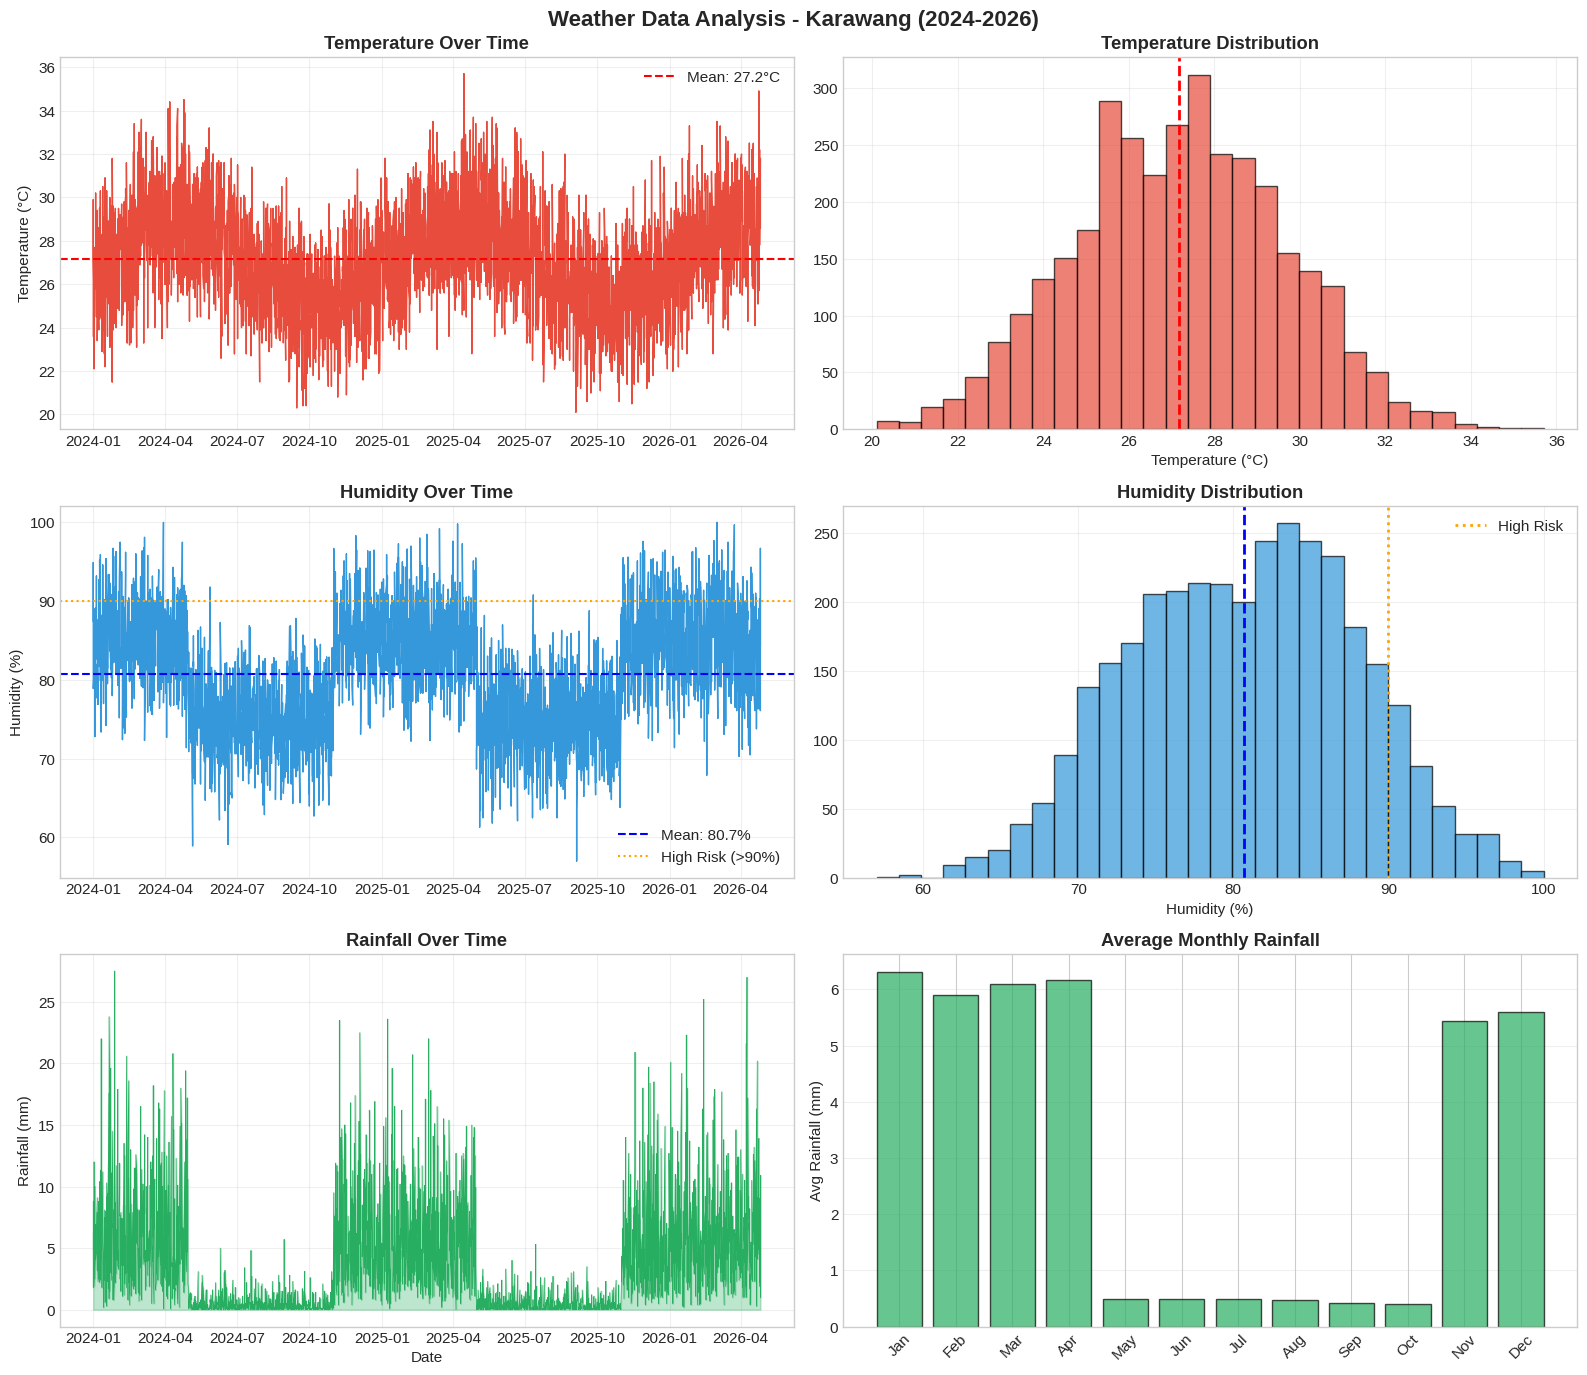

In [ ]:
# 7. Visualisasi Data Cuaca
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Weather Data Analysis - Karawang (2024-2026)', fontsize=16, fontweight='bold')

# Temperature
axes[0, 0].plot(weather_df['date'], weather_df['temperature'], color='#e74c3c', linewidth=1)
axes[0, 0].axhline(y=weather_df['temperature'].mean(), color='red', linestyle='--', label=f"Mean: {weather_df['temperature'].mean():.1f}°C")
axes[0, 0].set_title('Temperature Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(weather_df['temperature'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(weather_df['temperature'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Temperature Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].grid(True, alpha=0.3)

# Humidity
axes[1, 0].plot(weather_df['date'], weather_df['humidity'], color='#3498db', linewidth=1)
axes[1, 0].axhline(y=weather_df['humidity'].mean(), color='blue', linestyle='--', label=f"Mean: {weather_df['humidity'].mean():.1f}%")
axes[1, 0].axhline(y=90, color='orange', linestyle=':', label='High Risk (>90%)')
axes[1, 0].set_title('Humidity Over Time', fontweight='bold')
axes[1, 0].set_ylabel('Humidity (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(weather_df['humidity'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(weather_df['humidity'].mean(), color='blue', linestyle='--', linewidth=2)
axes[1, 1].axvline(90, color='orange', linestyle=':', linewidth=2, label='High Risk')
axes[1, 1].set_title('Humidity Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Humidity (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Rainfall
axes[2, 0].plot(weather_df['date'], weather_df['rainfall'], color='#27ae60', linewidth=0.5)
axes[2, 0].fill_between(weather_df['date'], weather_df['rainfall'], alpha=0.3, color='#27ae60')
axes[2, 0].set_title('Rainfall Over Time', fontweight='bold')
axes[2, 0].set_ylabel('Rainfall (mm)')
axes[2, 0].set_xlabel('Date')
axes[2, 0].grid(True, alpha=0.3)

# Monthly rainfall
weather_df['month'] = pd.to_datetime(weather_df['date']).dt.month
monthly_rain = weather_df.groupby('month')['rainfall'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[2, 1].bar(range(1, 13), monthly_rain.values, color='#27ae60', alpha=0.7, edgecolor='black')
axes[2, 1].set_xticks(range(1, 13))
axes[2, 1].set_xticklabels(month_names, rotation=45)
axes[2, 1].set_title('Average Monthly Rainfall', fontweight='bold')
axes[2, 1].set_ylabel('Avg Rainfall (mm)')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Visualisasi Data Satelit dan Integrasi Cuaca-Satelit


      count      mean       std    min    25%    50%    75%    max
ndvi  121.0  0.669446  0.156987  0.097  0.591  0.695  0.775  0.900
ndwi  121.0 -0.001992  0.054172 -0.129 -0.035 -0.007  0.032  0.184
evi   121.0  0.735868  0.166474  0.099  0.656  0.769  0.847  0.950
savi  121.0  0.633339  0.150486  0.097  0.554  0.656  0.743  0.879


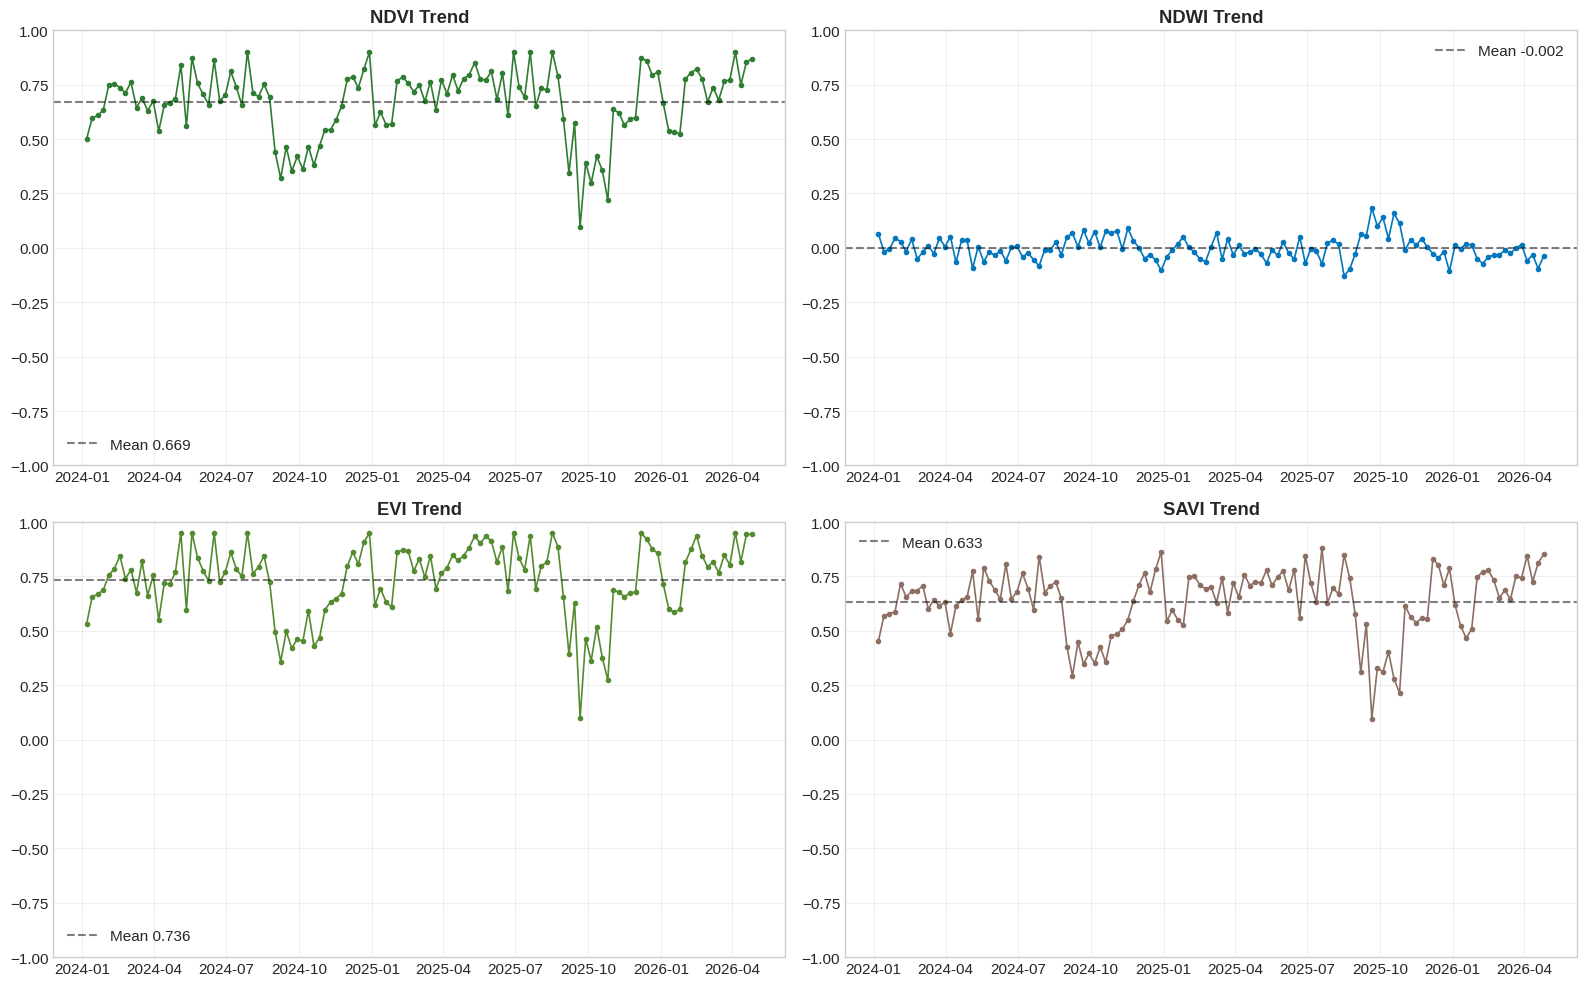

Merged weather-satellite shape: (847, 13)
        date  temperature  humidity  wind_speed  cloud_cover  pressure  \
0 2024-01-01       26.925    86.825       3.425       42.250  1008.700   
1 2024-01-02       24.950    83.025       2.625       36.625  1012.100   
2 2024-01-03       26.875    82.225       6.775       36.750  1012.925   
3 2024-01-04       28.025    86.800       3.125       41.550  1017.675   
4 2024-01-05       27.250    87.425       4.575       47.150  1017.500   

   dew_point  rainfall  ndvi  ndwi  evi  savi  anomaly  
0     24.250      21.7   NaN   NaN  NaN   NaN      NaN  
1     21.600      23.5   NaN   NaN  NaN   NaN      NaN  
2     23.300      25.5   NaN   NaN  NaN   NaN      NaN  
3     25.375      21.2   NaN   NaN  NaN   NaN      NaN  
4     24.750      23.7   NaN   NaN  NaN   NaN      NaN  


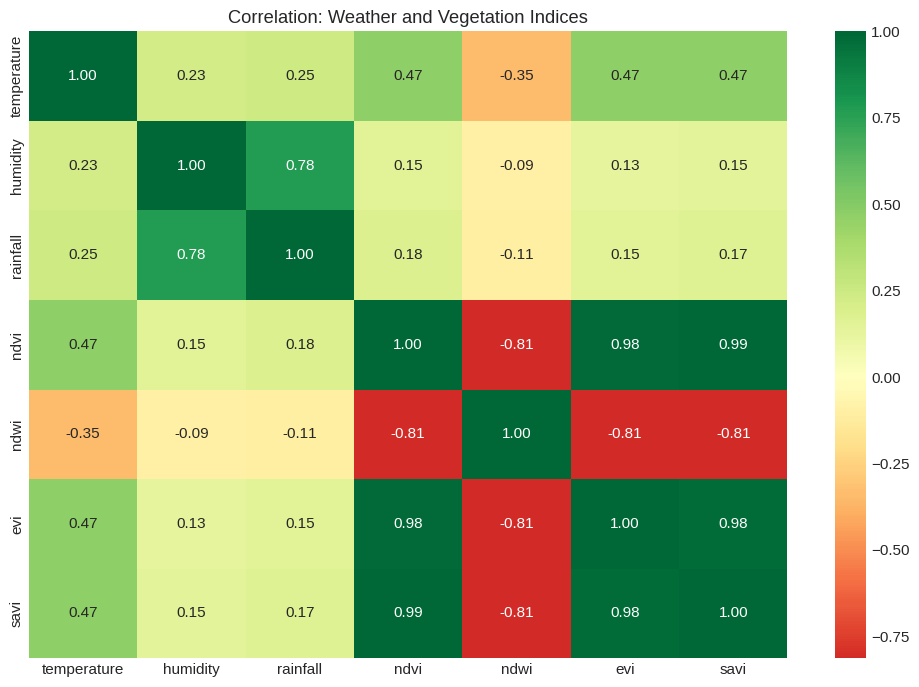

In [ ]:
# Visualisasi data satelit dan integrasi cuaca-satelit
print(satellite_df[veg_cols].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors = {'ndvi': '#2e7d32', 'ndwi': '#0277bd', 'evi': '#558b2f', 'savi': '#8d6e63'}

for idx, col in enumerate(veg_cols[:4]):
    axes[idx].plot(satellite_df['date'], satellite_df[col], marker='o', markersize=3, linewidth=1.2, color=colors.get(col, '#333333'))
    axes[idx].axhline(satellite_df[col].mean(), linestyle='--', color='black', alpha=0.5, label=f"Mean {satellite_df[col].mean():.3f}")
    axes[idx].set_title(f'{col.upper()} Trend', fontweight='bold')
    axes[idx].set_ylim(-1, 1)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(veg_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

weather_daily = weather_df.copy()
weather_numeric_cols = [col for col in ['temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover', 'pressure', 'dew_point'] if col in weather_daily.columns]
if 'station_name' in weather_daily.columns:
    agg_dict = {col: 'mean' for col in weather_numeric_cols if col != 'rainfall'}
    if 'rainfall' in weather_numeric_cols:
        agg_dict['rainfall'] = 'sum'
    weather_daily = weather_daily.groupby('date', as_index=False).agg(agg_dict)

satellite_features = satellite_df[['date'] + [col for col in ['ndvi', 'ndwi', 'evi', 'savi', 'anomaly'] if col in satellite_df.columns]].sort_values('date')
merged_df = pd.merge_asof(
    weather_daily.sort_values('date'),
    satellite_features,
    on='date',
    direction='backward',
    tolerance=pd.Timedelta(days=14),
)

print(f"Merged weather-satellite shape: {merged_df.shape}")
print(merged_df.head())

corr_cols = [col for col in ['temperature', 'humidity', 'rainfall', 'ndvi', 'ndwi', 'evi', 'savi'] if col in merged_df.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(merged_df[corr_cols].corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
    plt.title('Correlation: Weather and Vegetation Indices')
    plt.tight_layout()
    plt.show()


## 8. Distribusi Kelas Dataset Gambar

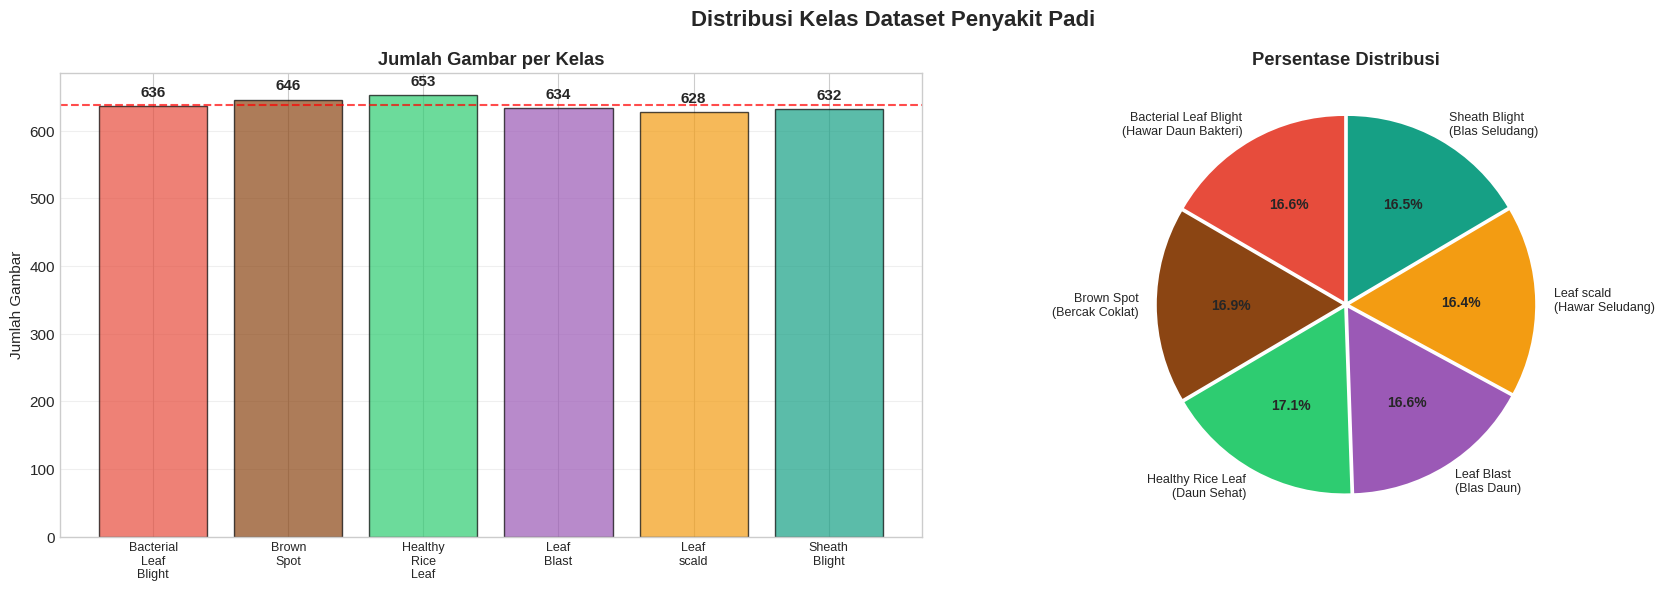


 Distribusi per Kelas:
----------------------------------------------------------------------
Bacterial Leaf Blight    :  636 ( 16.6%) | Expected:  636 | Diff:   +0
Brown Spot               :  646 ( 16.9%) | Expected:  646 | Diff:   +0
Healthy Rice Leaf        :  653 ( 17.1%) | Expected:  653 | Diff:   +0
Leaf Blast               :  634 ( 16.6%) | Expected:  634 | Diff:   +0
Leaf scald               :  628 ( 16.4%) | Expected:  628 | Diff:   +0
Sheath Blight            :  632 ( 16.5%) | Expected:  632 | Diff:   +0
----------------------------------------------------------------------


In [ ]:
# 8. Distribusi Kelas Dataset Gambar
if len(image_df) > 0:
    class_counts = image_df['class'].value_counts().sort_index()
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Distribusi Kelas Dataset Penyakit Padi', fontsize=16, fontweight='bold')

    # Bar chart
    colors = [CLASS_COLORS.get(c, '#3498db') for c in class_counts.index]
    bars = axes[0].bar(range(len(class_counts)), class_counts.values, color=colors, alpha=0.7, edgecolor='black')
    axes[0].set_xticks(range(len(class_counts)))
    axes[0].set_xticklabels([c.replace(' ', '\n') for c in class_counts.index], rotation=0, fontsize=9)
    axes[0].set_title('Jumlah Gambar per Kelas', fontweight='bold')
    axes[0].set_ylabel('Jumlah Gambar')
    axes[0].grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, class_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{count}', ha='center', va='bottom', fontweight='bold')

    expected_avg = sum([CLASSES[c]['expected_count'] for c in class_counts.index]) / len(class_counts)
    axes[0].axhline(y=expected_avg, color='red', linestyle='--', alpha=0.7)

    # Pie chart
    wedges, texts, autotexts = axes[1].pie(
        class_counts.values,
        labels=[f"{c}\n({CLASSES[c]['nama_indonesia']})" for c in class_counts.index],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.02] * len(class_counts),
        textprops={'fontsize': 9}
    )
    axes[1].set_title('Persentase Distribusi', fontweight='bold')
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n Distribusi per Kelas:")
    print("-" * 70)
    for class_name in CLASSES.keys():
        count = (image_df['class'] == class_name).sum()
        pct = count / len(image_df) * 100 if len(image_df) > 0 else 0
        expected = CLASSES[class_name]['expected_count']
        diff = count - expected
        print(f"{class_name:25s}: {count:4d} ({pct:5.1f}%) | Expected: {expected:4d} | Diff: {diff:+4d}")
    print("-" * 70)

## 9. Sample Images per Kelas

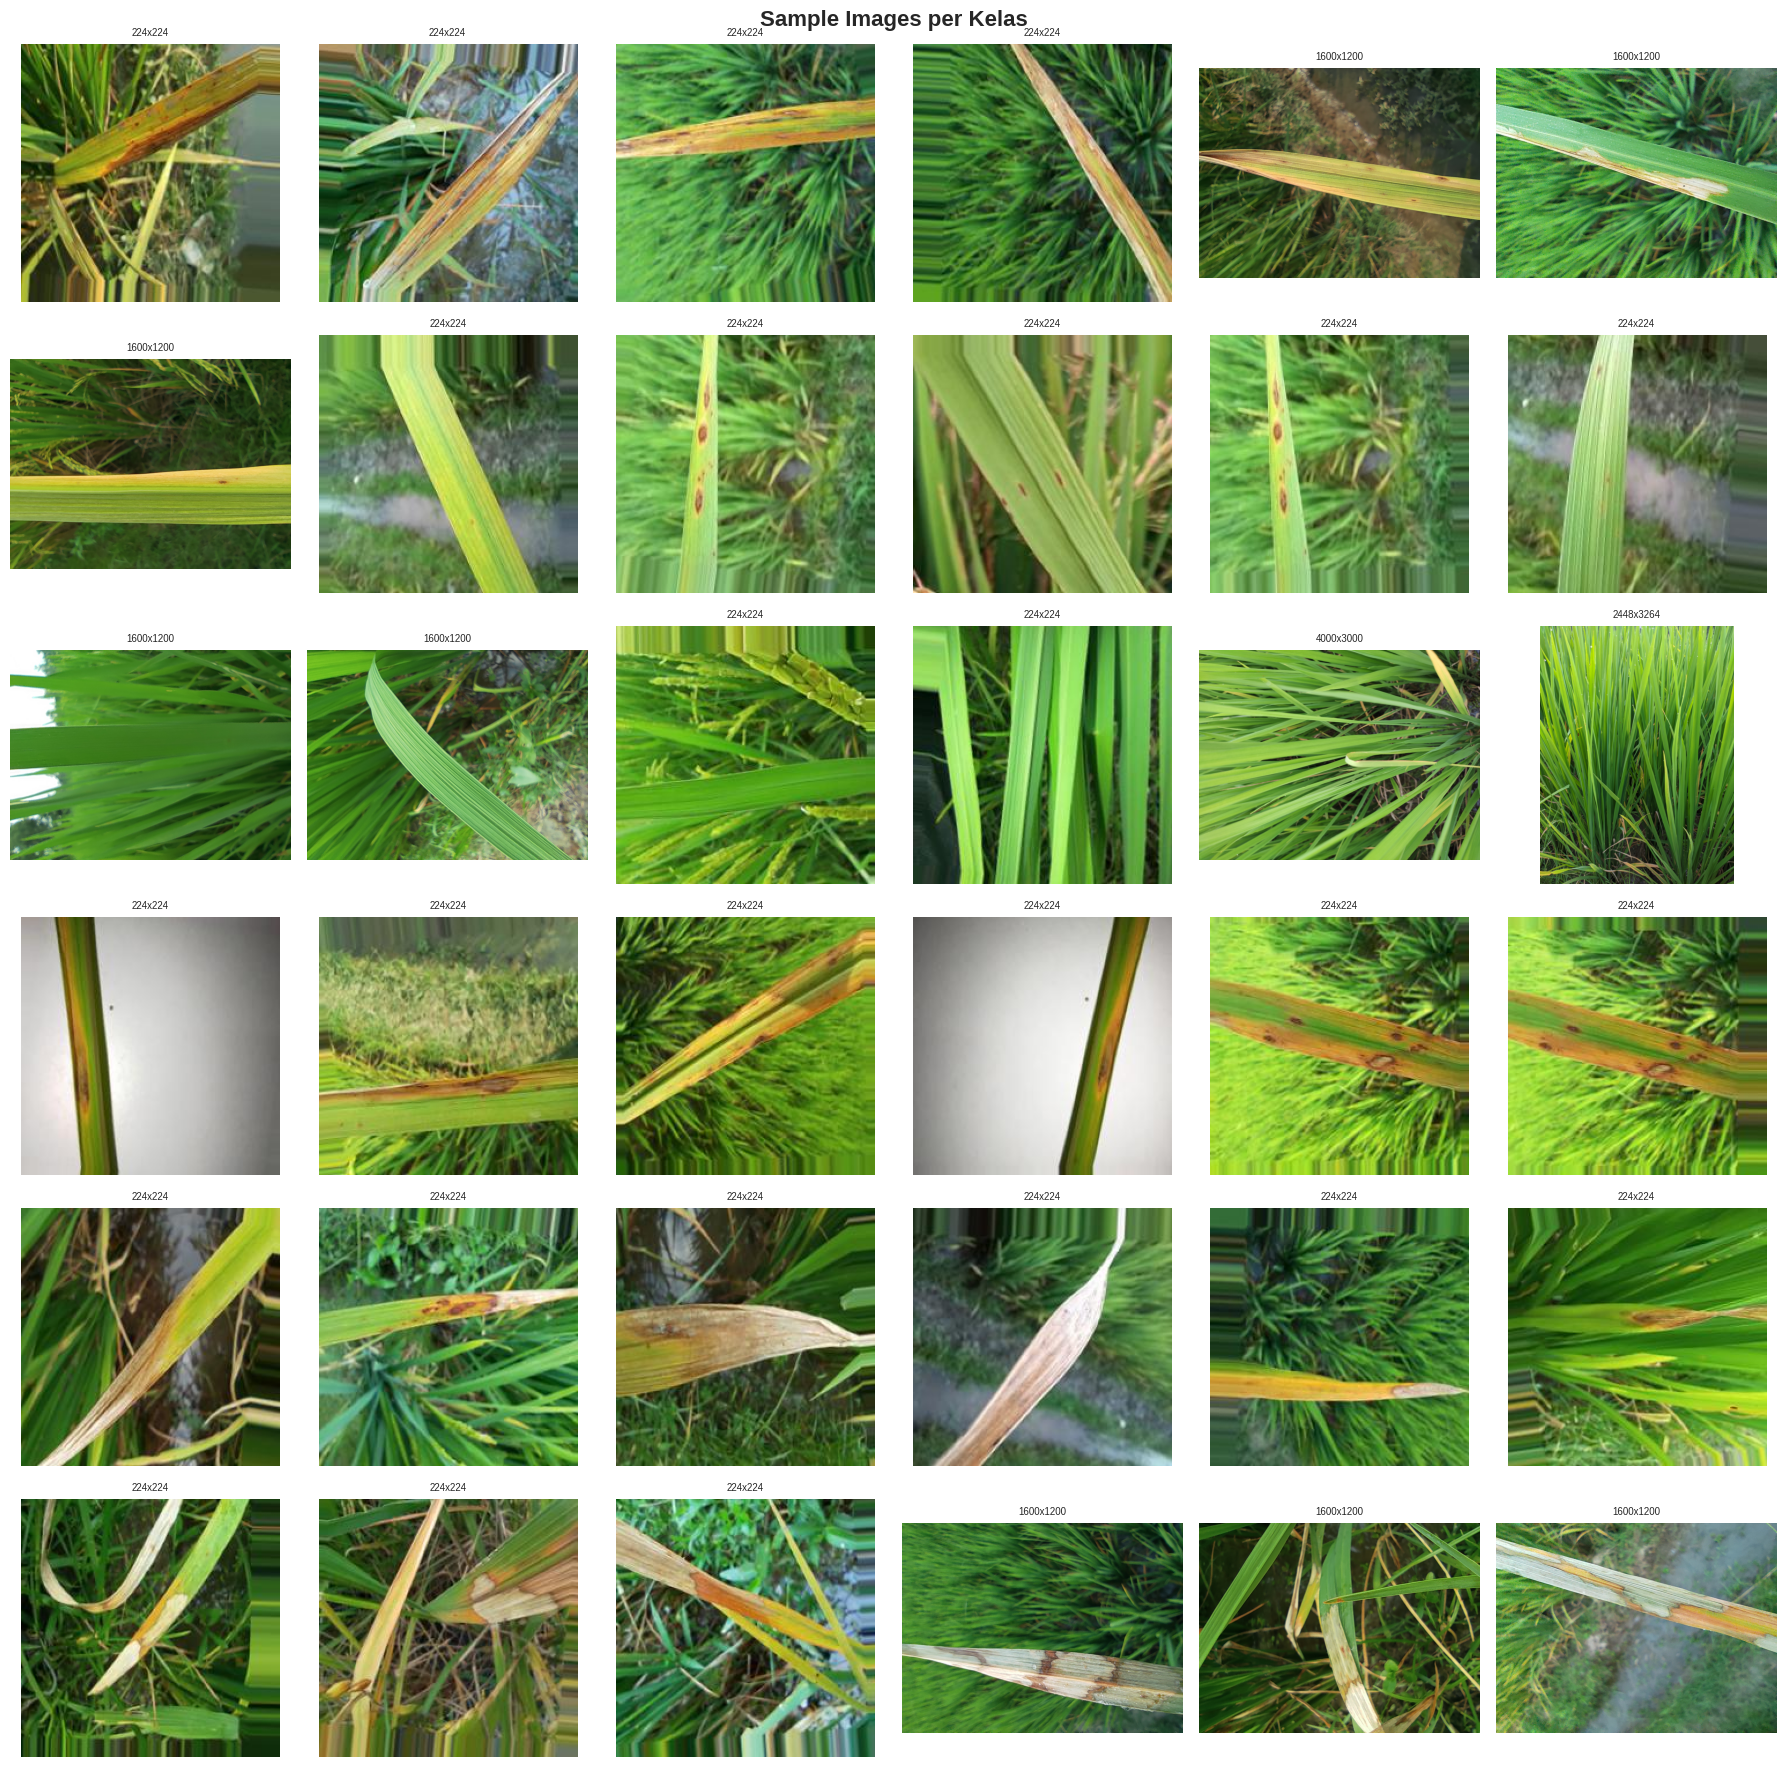

In [ ]:
# 9. Sample Images per Kelas
if len(image_df) > 0:
    n_samples = 6
    fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(18, 3*len(CLASSES)))
    fig.suptitle('Sample Images per Kelas', fontsize=16, fontweight='bold')

    for idx, (class_name, class_info) in enumerate(CLASSES.items()):
        class_df = image_df[image_df['class'] == class_name]
        if len(class_df) > 0:
            samples = class_df.sample(min(n_samples, len(class_df)), random_state=42)
            for col, (_, row) in enumerate(samples.iterrows()):
                try:
                    img = Image.open(row['filepath'])
                    axes[idx, col].imshow(img)
                    axes[idx, col].axis('off')
                    if col == 0:
                        label = f"{class_name}\n({class_info['nama_indonesia']})"
                        axes[idx, col].set_ylabel(label, fontsize=8, fontweight='bold')
                    axes[idx, col].set_title(f"{row['width']}x{row['height']}", fontsize=7)
                except:
                    axes[idx, col].text(0.5, 0.5, "Error", ha='center', va='center')
                    axes[idx, col].axis('off')
        else:
            for col in range(n_samples):
                axes[idx, col].text(0.5, 0.5, "No images", ha='center', va='center')
                axes[idx, col].axis('off')

    plt.tight_layout()
    plt.show()

## 10. Analisis Dimensi Gambar

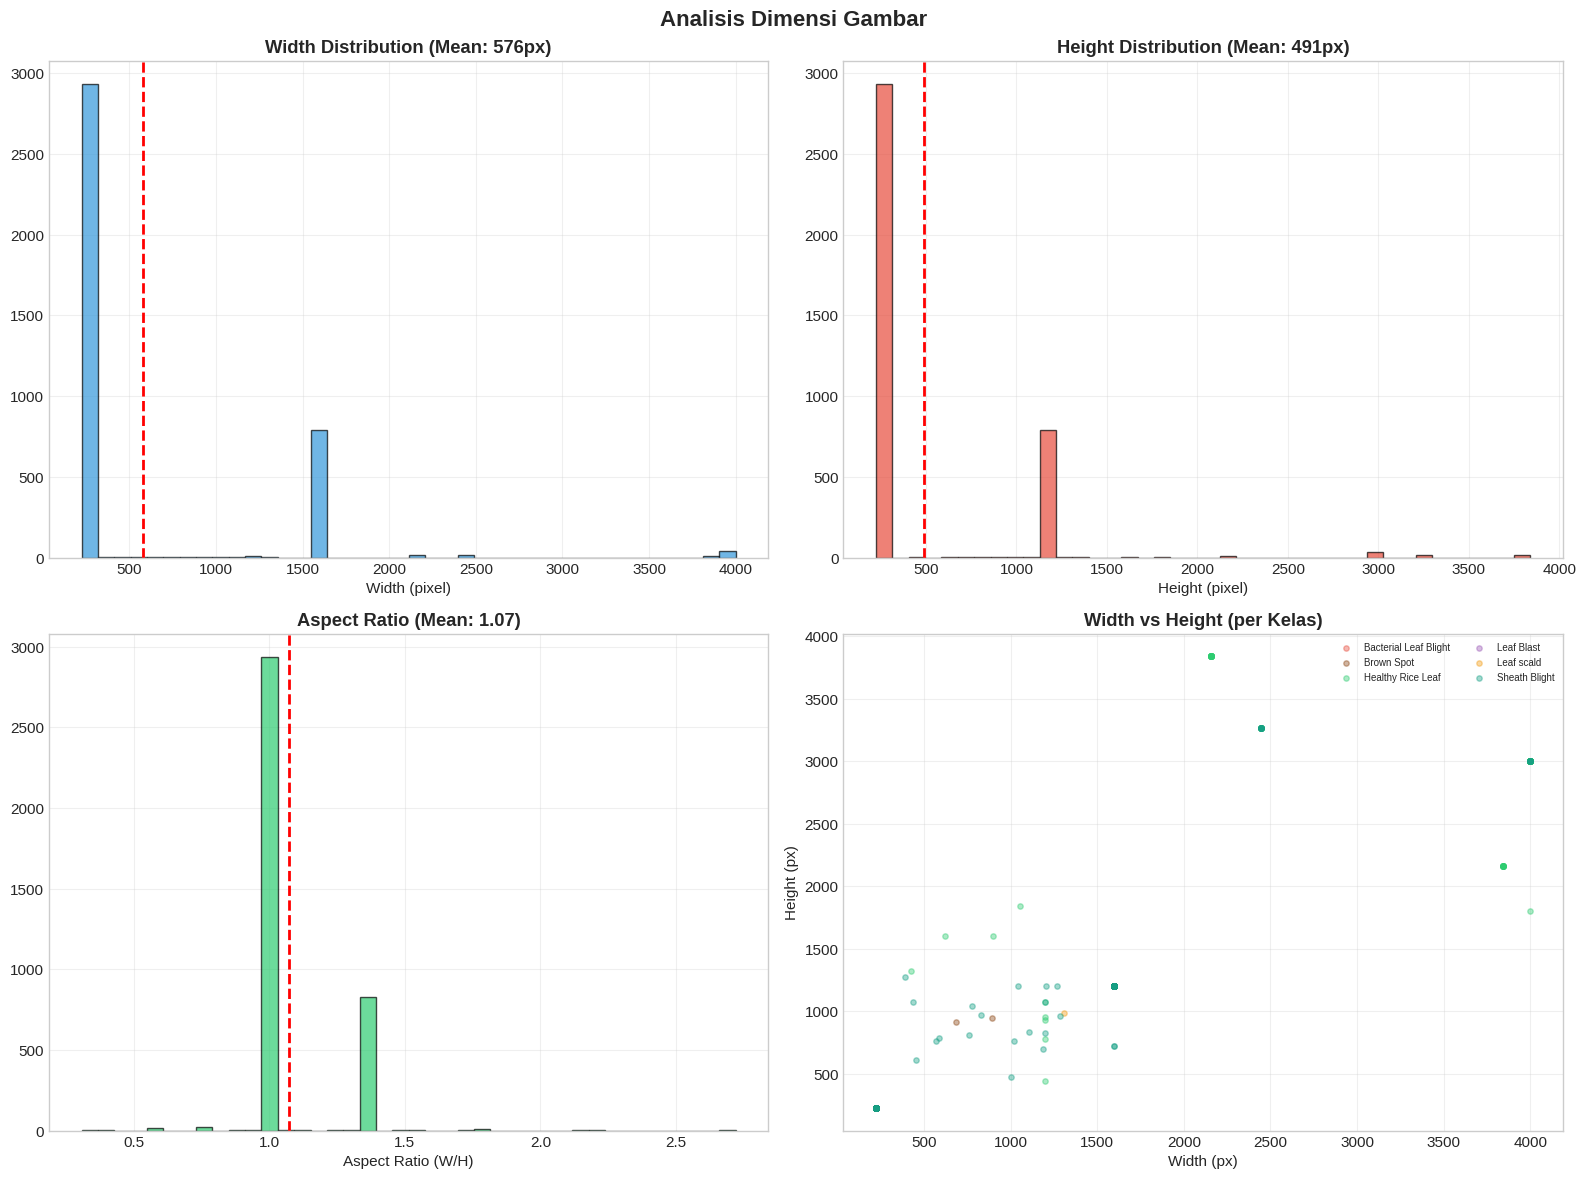

In [ ]:
# 10. Analisis Dimensi Gambar
if len(image_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Analisis Dimensi Gambar', fontsize=16, fontweight='bold')

    # Width
    axes[0, 0].hist(image_df['width'], bins=40, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(image_df['width'].mean(), color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title(f'Width Distribution (Mean: {image_df["width"].mean():.0f}px)', fontweight='bold')
    axes[0, 0].set_xlabel('Width (pixel)')
    axes[0, 0].grid(True, alpha=0.3)

    # Height
    axes[0, 1].hist(image_df['height'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(image_df['height'].mean(), color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title(f'Height Distribution (Mean: {image_df["height"].mean():.0f}px)', fontweight='bold')
    axes[0, 1].set_xlabel('Height (pixel)')
    axes[0, 1].grid(True, alpha=0.3)

    # Aspect Ratio
    axes[1, 0].hist(image_df['aspect_ratio'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(image_df['aspect_ratio'].mean(), color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_title(f'Aspect Ratio (Mean: {image_df["aspect_ratio"].mean():.2f})', fontweight='bold')
    axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
    axes[1, 0].grid(True, alpha=0.3)

    # Scatter per class
    for class_name in CLASSES.keys():
        class_df = image_df[image_df['class'] == class_name]
        axes[1, 1].scatter(class_df['width'], class_df['height'], label=class_name, alpha=0.4, s=15, color=CLASS_COLORS.get(class_name, '#3498db'))

    axes[1, 1].set_title('Width vs Height (per Kelas)', fontweight='bold')
    axes[1, 1].set_xlabel('Width (px)')
    axes[1, 1].set_ylabel('Height (px)')
    axes[1, 1].legend(fontsize=7, ncol=2)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 11. Analisis Produksi & Dampak Ekonomi

Loaded production: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/dataset_produksi_padi_karawang_cleaned.csv | shape=(185, 8)


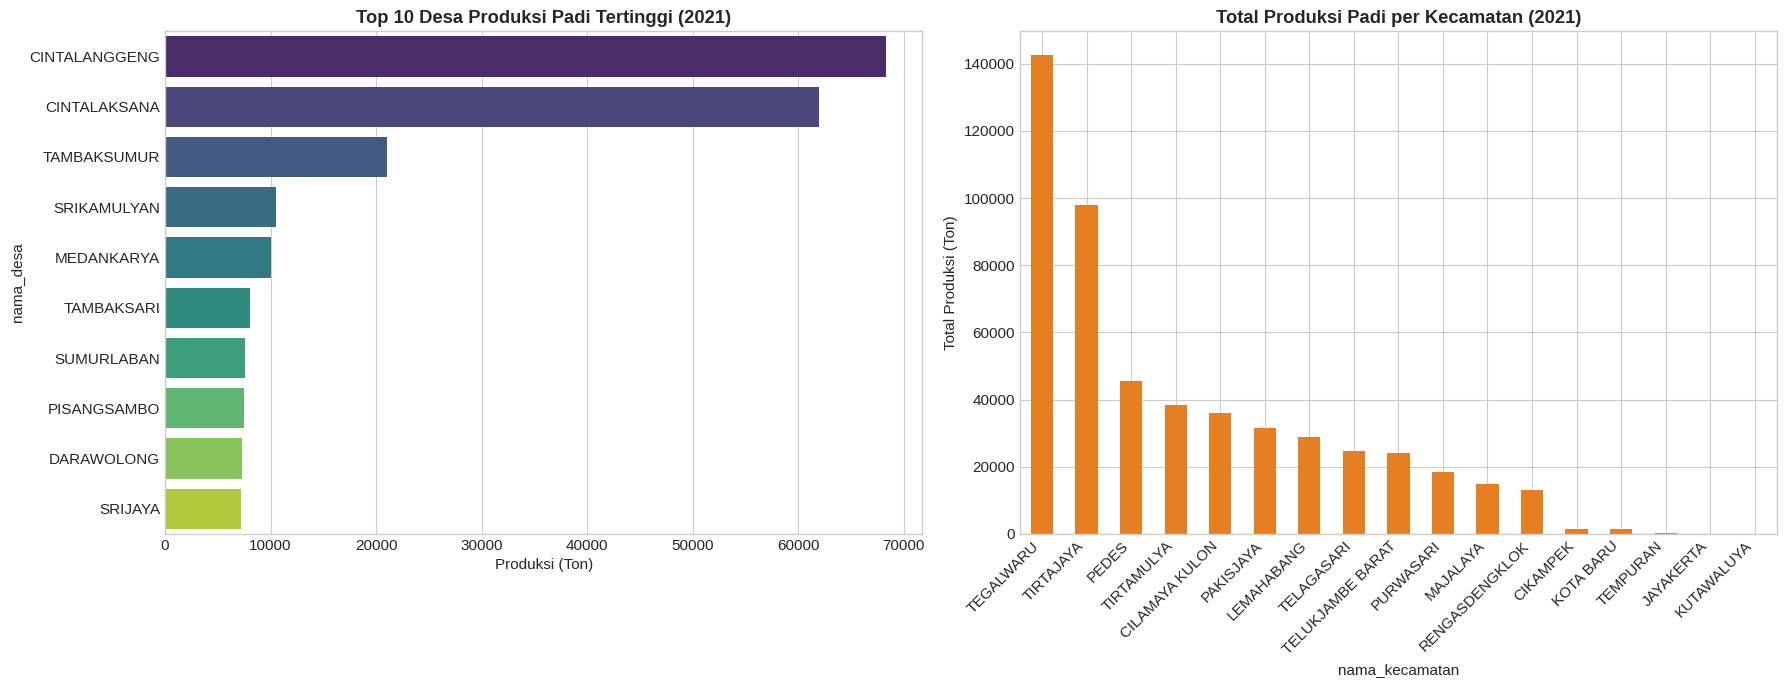

Total Produksi Terpetakan (2021): 518,784.59 Ton
Estimasi Nilai Ekonomi: Rp 3,112,707,570,000
Estimasi Value at Risk 20-40%: Rp 622,541,514,000 - Rp 1,245,083,028,000

Data Provenance:
                         source_type  \
weather     uploaded_or_project_file   
satellite   uploaded_or_project_file   
production  uploaded_or_project_file   

                                                         path  rows  
weather     /content/drive/MyDrive/Datathon/KarawangPadiGu...  3388  
satellite   /content/drive/MyDrive/Datathon/KarawangPadiGu...   121  
production  /content/drive/MyDrive/Datathon/KarawangPadiGu...   185  


In [ ]:
# Load data produksi dari file yang kamu upload sendiri
production_df = load_required_dataset(
    dataset_name='production',
    required_columns=['tahun', 'produksi_padi'],
    standardizer=None,
)
production_df.columns = [col.strip() for col in production_df.columns]
production_df['tahun'] = pd.to_numeric(production_df['tahun'], errors='coerce').astype('Int64')
production_df['produksi_padi'] = pd.to_numeric(production_df['produksi_padi'], errors='coerce')
production_df = production_df.dropna(subset=['tahun', 'produksi_padi']).reset_index(drop=True)

latest_year = int(production_df['tahun'].dropna().max())
df_prod_2021 = production_df[production_df['tahun'] == latest_year]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if 'nama_desa' in df_prod_2021.columns:
    top_desa = df_prod_2021.sort_values('produksi_padi', ascending=False).head(10)
    sns.barplot(data=top_desa, x='produksi_padi', y='nama_desa', ax=axes[0], palette='viridis')
    axes[0].set_title(f'Top 10 Desa Produksi Padi Tertinggi ({latest_year})', fontweight='bold')
    axes[0].set_xlabel('Produksi (Ton)')
else:
    axes[0].axis('off')
    axes[0].set_title('Kolom nama_desa tidak tersedia')

if 'nama_kecamatan' in df_prod_2021.columns:
    kec_prod = df_prod_2021.groupby('nama_kecamatan')['produksi_padi'].sum().sort_values(ascending=False)
    kec_prod.plot(kind='bar', ax=axes[1], color='#e67e22')
    axes[1].set_title(f'Total Produksi Padi per Kecamatan ({latest_year})', fontweight='bold')
    axes[1].set_ylabel('Total Produksi (Ton)')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
else:
    axes[1].axis('off')
    axes[1].set_title('Kolom nama_kecamatan tidak tersedia')

plt.tight_layout()
plt.show()

avg_price_per_ton = 6000000
total_prod = df_prod_2021['produksi_padi'].sum()
total_value = total_prod * avg_price_per_ton
potential_loss_low = total_value * 0.20
potential_loss_high = total_value * 0.40

print(f"Total Produksi Terpetakan ({latest_year}): {total_prod:,.2f} Ton")
print(f"Estimasi Nilai Ekonomi: Rp {total_value:,.0f}")
print(f"Estimasi Value at Risk 20-40%: Rp {potential_loss_low:,.0f} - Rp {potential_loss_high:,.0f}")

print("\nData Provenance:")
print(pd.DataFrame(DATA_PROVENANCE).T[['source_type', 'path', 'rows']])